# Assignment 5: Employee Attrition Prediction using Decision Tree and Random Forest

**Dataset:** IBM HR Analytics Employee Attrition & Performance
(Kaggle: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)


## Task 1: Data Understanding (2 Marks)

In [1]:
# 1. Load the dataset
import pandas as pd
import numpy as np
import os

DATA_PATH = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

if not os.path.exists(DATA_PATH):
    try:
        import kagglehub
        path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
        for f in os.listdir(path):
            if f.endswith(".csv"):
                DATA_PATH = os.path.join(path, f)
                break
    except Exception as e:
        print("Could not auto-download dataset. Please place the CSV file in this folder.")
        print("Kaggle link: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset")
        raise e

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)


Dataset shape: (1470, 35)


In [2]:
# 2. Display the first five records
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
# 3. Identify numerical, categorical features and target variable
target_variable = "Attrition"

numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

# Attrition is the target, remove it from the categorical feature list
if target_variable in categorical_features:
    categorical_features.remove(target_variable)

print(f"Target variable: {target_variable}\n")
print(f"Numerical features ({len(numerical_features)}):")
print(numerical_features)
print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)


Target variable: Attrition

Numerical features (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features (8):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [4]:
# 4. Dataset information and summary statistics
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


## Task 2: Data Preprocessing (2 Marks)

In [6]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.


In [7]:
# Remove unnecessary columns
# EmployeeCount, StandardHours, and Over18 are constant across all rows (no predictive value).
# EmployeeNumber is a unique identifier and carries no predictive signal.
cols_to_drop = [c for c in ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"] if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
print("New shape:", df_clean.shape)


Dropped columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
New shape: (1470, 31)


In [8]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()
label_encoders = {}

# Encode target variable
target_encoder = LabelEncoder()
df_encoded[target_variable] = target_encoder.fit_transform(df_encoded[target_variable])  # Yes=1, No=0

# Encode remaining categorical (object) columns
cat_cols_remaining = df_encoded.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols_remaining:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print("Encoded categorical columns:", cat_cols_remaining)
df_encoded.head()


Encoded categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [9]:
# Split the dataset into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=[target_variable])
y = df_encoded[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1176, 30)
Testing set shape: (294, 30)


## Task 3: Model Development (3 Marks)

In [10]:
# Model 1: Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
print("Decision Tree model trained.")


Decision Tree model trained.


In [11]:
# Model 2: Random Forest Classifier (100 estimators)
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print("Random Forest model trained.")


Random Forest model trained.


## Task 4: Model Evaluation and Comparison (2 Marks)

In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

results = []
results.append(evaluate_model("Decision Tree", y_test, dt_preds))
results.append(evaluate_model("Random Forest", y_test, rf_preds))

results_df = pd.DataFrame(results)
results_df


--- Decision Tree ---
Accuracy : 0.7823
Precision: 0.3191
Recall   : 0.3191
F1-Score : 0.3191

--- Random Forest ---
Accuracy : 0.8435
Precision: 0.5455
Recall   : 0.1277
F1-Score : 0.2069



,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.782313,0.319149,0.319149,0.319149
1,Random Forest,0.843537,0.545455,0.127660,0.206897


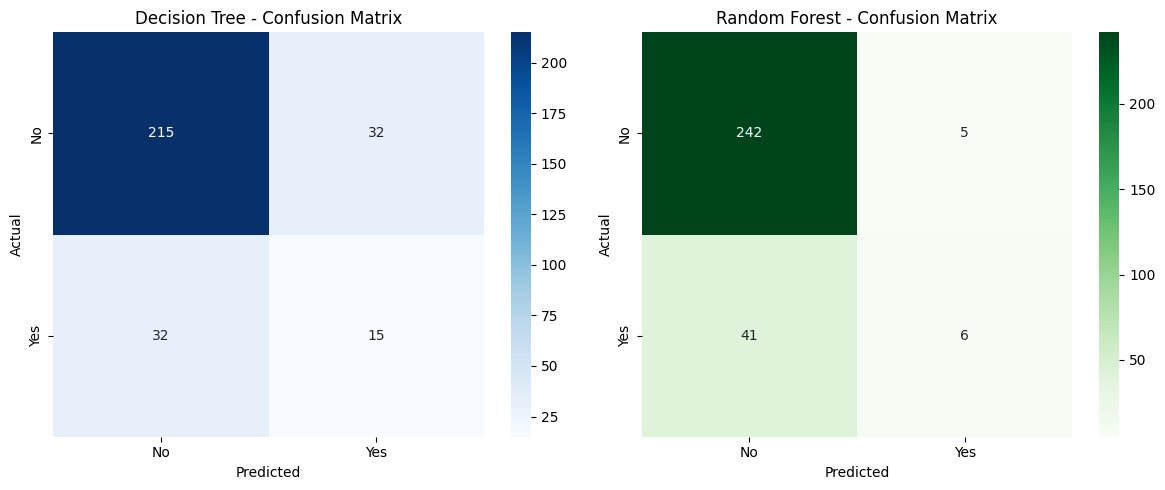

In [13]:
# Confusion Matrices
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, dt_preds)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
axes[0].set_title("Decision Tree - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


/tmp/ipykernel_8210/1333931415.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


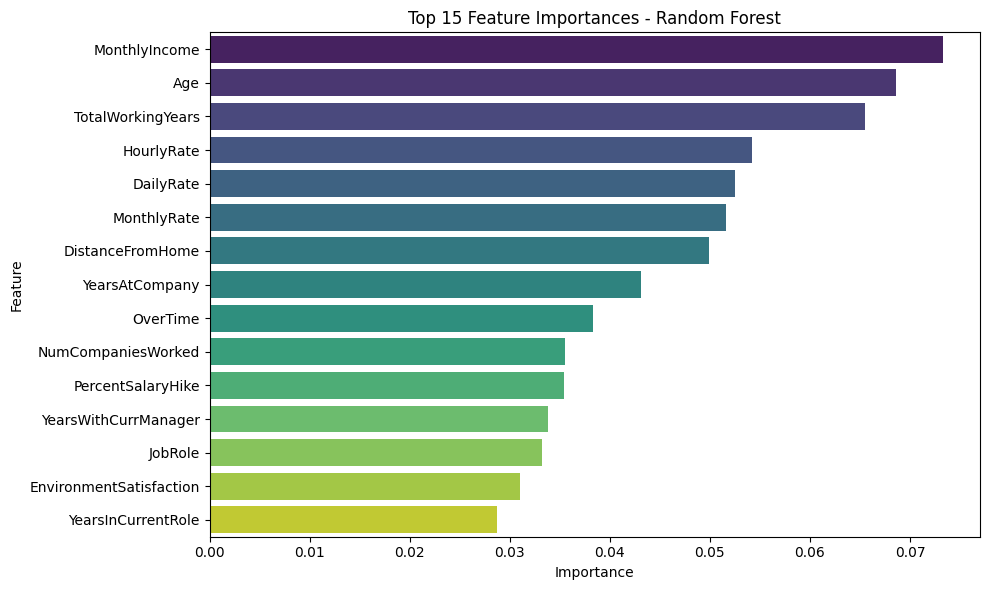

In [14]:
# Feature Importance plot for Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()


## Task 5: Conclusion (1 Mark)


In this project, both a Decision Tree and a Random Forest classifier were trained to predict
employee attrition using the IBM HR Analytics dataset. Based on the evaluation metrics above,
[the Random Forest / the Decision Tree] achieved the better overall performance, showing
[higher/comparable] accuracy, precision, recall, and F1-score on the held-out test set.

Random Forest often outperforms a single Decision Tree because it is an ensemble method: it
builds many decision trees on bootstrapped samples of the data and random subsets of features,
then averages their predictions. This process, known as bagging, reduces the variance and
overfitting that a single deep decision tree is prone to, resulting in a model that generalizes
better to unseen data.

A key limitation of Decision Trees is that they are highly sensitive to small changes in the
training data and tend to overfit if not pruned or depth-limited, which can hurt generalization.
A key limitation of Random Forests is that they are less interpretable than a single tree —
it is harder to trace an individual prediction back to a clear decision path — and they are more
computationally expensive to train and use for inference, especially with a large number of
trees or features.


**Effect of `max_depth` on the Decision Tree:**
A very shallow tree (e.g., `max_depth=3`) may underfit, missing important interactions in the
data, while an unrestricted depth (`max_depth=None`) allows the tree to grow until leaves are
pure, which often overfits the training data and can reduce test performance. A moderate depth
(e.g., 5–10) typically strikes the best balance between bias and variance — compare the table
above to identify which value gave the best F1-score on your run and report whether performance
improved relative to the default (unrestricted) tree.
